# Cross-Ensemble Sybil Detector — LayerZero

Combines the XGBoost and LightGBM 3-seed ensembles via weighted probability averaging (soft voting):

```
final_score = w × P(Sybil | XGBoost) + (1 − w) × P(Sybil | LightGBM)
```

`w` is selected on validation F1 (section 6); the test set is not used to choose it.

**Agreement**: section 8 reports how often the two models disagree at threshold 0.5 and how the ensemble does there.

**Results**: printed in section 7 and saved to `results/04_cross_ensemble_<split>.json`.

**Runtime**: ~15 minutes total (6 models × ~90s each)

## 1. Setup

In [1]:
# Install required packages (run once)
# !pip install xgboost lightgbm scikit-learn pandas numpy matplotlib

In [2]:
import os, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    brier_score_loss, average_precision_score
)

import sybil_pipeline as sp

warnings.filterwarnings('ignore')
SEED = sp.SEED

In [3]:
# ── Set this to the folder containing all data files ──────────
DATA_DIR = './data'   # <-- adjust if needed

# 'group'  = stratified group split by funding cluster (revision default)
# 'random' = address-level split used in the original paper
SPLIT_METHOD = os.environ.get('SPLIT_METHOD', 'group')

FEATS = sp.FEATS   # 62 model features (defined in sybil_pipeline.py)
print(f'Split method: {SPLIT_METHOD}  |  {len(FEATS)} features')

DATA_DIR : ./data
Features : 63


## 2. Data Loading

In [15]:
# ── Build the master feature table (steps 1-7; see 00_data_pipeline) ──
df, tfm, labeled_anchors = sp.build_master_df(DATA_DIR)

[1] L0 features: 434,786 addresses, 55 cols  (4.0s)
[2] Gas provision: 604,661 mappings  (6.6s)
[3] Labeled anchors: 3,698  (5.9s)
[4] Tree features merged: 434,787 rows, 89 cols  (2.8s)
[5] CEX/DEX merged: 434,787 rows, 91 cols  (1.6s)
[6] Labels: Sybil=18,211 (4.19%)  (0.7s)
[7] Chain features: mean=1.88, max=504  (1.4s)
All 63 features present ✓


## 3. Train / Validation / Test Split

In [16]:
# ── Train / Val / Test split + minority upsampling ────────────
# 49 / 21 / 30 partitions. With SPLIT_METHOD='group', no funding group
# spans two partitions (asserted inside sp.make_splits).
S = sp.make_splits(df, FEATS, method=SPLIT_METHOD, seed=SEED)
X_train, y_train = S['X_train'], S['y_train']
X_val,   y_val   = S['X_val'],   S['y_val']
X_test,  y_test  = S['X_test'],  S['y_test']

print(sp.split_summary(df, S).to_string(index=False))
print(f'Train after upsampling: {len(X_train):,} rows ({y_train.mean()*100:.1f}% Sybil)\n')
leak = sp.leakage_report(df, S)

Train (balanced) : 408,242  (50.0% Sybil)
Validation       : 91,305   (4.19% Sybil)
Test             : 130,437  (4.19% Sybil)


## 4. Evaluation Helpers

In [17]:
# ── Evaluation helpers ────────────────────────────────────────
def optimal_threshold(y_true, probs):
    """Find threshold that maximises F1 on the given set."""
    prec, rec, thresholds = precision_recall_curve(y_true, probs)
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0)
    return float(thresholds[np.argmax(f1[:-1])])

def evaluate(name, val_probs, test_probs, y_val, y_test, threshold=None):
    """Evaluate model at optimal val threshold, report test metrics."""
    thr = threshold if threshold is not None else optimal_threshold(y_val, val_probs)
    y_pred = (test_probs >= thr).astype(int)
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    prc, rec, _ = precision_recall_curve(y_test, test_probs)
    results = dict(
        name      = name,
        threshold = thr,
        precision = precision_score(y_test, y_pred, zero_division=0),
        recall    = recall_score(y_test, y_pred,    zero_division=0),
        f1        = f1_score(y_test, y_pred,         zero_division=0),
        auroc     = auc(fpr, tpr),
        ap        = average_precision_score(y_test, test_probs),
        brier     = brier_score_loss(y_test, test_probs),
        fpr=fpr, tpr=tpr, prc=prc, rec_c=rec,
    )
    print(f'  Threshold : {thr:.4f}')
    print(f'  Precision : {results["precision"]:.4f}')
    print(f'  Recall    : {results["recall"]:.4f}')
    print(f'  F1        : {results["f1"]:.4f}')
    print(f'  AUROC     : {results["auroc"]:.4f}')
    print(f'  Avg Prec  : {results["ap"]:.4f}')
    print(f'  Brier     : {results["brier"]:.4f}')
    print(classification_report(y_test, y_pred, digits=4))
    return results

def plot_curves(results_list):
    """Plot ROC and PR curves for one or more models."""
    colors = ['#1565C0','#2E7D32','#B71C1C','#6A1B9A','#E65100']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for r, c in zip(results_list, colors):
        axes[0].plot(r['fpr'], r['tpr'], color=c, lw=2,
                     label=f"{r['name']}  AUC={r['auroc']:.4f}")
        axes[1].plot(r['rec_c'], r['prc'], color=c, lw=2,
                     label=f"{r['name']}  AP={r['ap']:.4f}")
    axes[0].plot([0,1],[0,1],'k--',alpha=0.3,lw=1)
    axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
    axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
    axes[1].legend(fontsize=9, loc='upper right'); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.show()

## 5. Train Both Models (6 total: 3 seeds × 2 frameworks)

In [18]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb_lib

# ── Model configurations ───────────────────────────────────────
XGB_SELECTED, LGBM_SELECTED = sp.load_selected_params()   # from 05_hyperparameter_search
XGB_PARAMS = dict(
    objective='binary:logistic', n_estimators=5000,
    eval_metric='logloss', early_stopping_rounds=50,
    verbosity=0, tree_method='hist',
    n_jobs=sp.N_JOBS,   # fixed: 'hist' results depend on thread count
    **XGB_SELECTED,
)
LGBM_PARAMS = dict(
    n_estimators=5000, subsample_freq=1, colsample_bytree=0.8,
    verbose=-1, n_jobs=sp.N_JOBS,
    **LGBM_SELECTED,
)
print('XGBoost params :', XGB_PARAMS)
print('LightGBM params:', LGBM_PARAMS)
SEEDS = [42, 123, 456]

# ── Train XGBoost seeds ────────────────────────────────────────
print('── XGBoost (3 seeds) ──')
xgb_val_list, xgb_test_list, xgb_rounds = [], [], []
for seed in SEEDS:
    t0 = time.time()
    m = XGBClassifier(**XGB_PARAMS, random_state=seed)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    xgb_rounds.append(int(m.best_iteration))
    xgb_val_list.append(m.predict_proba(X_val)[:,1])
    xgb_test_list.append(m.predict_proba(X_test)[:,1])
    print(f'  seed={seed}  iter={m.best_iteration}  {time.time()-t0:.1f}s')

xgb_val  = np.mean(xgb_val_list,  axis=0)
xgb_test = np.mean(xgb_test_list, axis=0)

# ── Train LightGBM seeds ───────────────────────────────────────
print('\n── LightGBM (3 seeds) ──')
lgbm_val_list, lgbm_test_list, lgbm_rounds = [], [], []
for seed in SEEDS:
    t0 = time.time()
    m = LGBMClassifier(**{**LGBM_PARAMS, 'random_state': seed})
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)],
          callbacks=[lgb_lib.early_stopping(50, verbose=False),
                     lgb_lib.log_evaluation(-1)])
    lgbm_rounds.append(int(m.best_iteration_))
    lgbm_val_list.append(m.predict_proba(X_val)[:,1])
    lgbm_test_list.append(m.predict_proba(X_test)[:,1])
    print(f'  seed={seed}  iter={m.best_iteration_}  {time.time()-t0:.1f}s')

lgbm_val  = np.mean(lgbm_val_list,  axis=0)
lgbm_test = np.mean(lgbm_test_list, axis=0)


── XGBoost (3 seeds) ──
  seed=42  iter=493  38.9s
  seed=123  iter=449  37.2s
  seed=456  iter=480  39.4s

── LightGBM (3 seeds) ──
  seed=42  iter=338  118.9s
  seed=123  iter=328  85.7s
  seed=456  iter=329  58.5s

Cross-ensemble: 0.4×XGB + 0.6×LGBM


## 6. Blend Weight Selection (validation set only)

For each XGBoost weight *w* in 0.00 to 1.00 (step 0.02), blend the validation probabilities, take the F1-maximising threshold on validation, and record validation F1. The weight with the highest validation F1 is used. The test set is not touched here.

In [ ]:
# ── Blend weight: selected on the validation set only ─────────
weights = np.round(np.linspace(0, 1, 51), 2)
val_f1 = []
for w in weights:
    blended_val = w * xgb_val + (1 - w) * lgbm_val
    thr = optimal_threshold(y_val, blended_val)
    val_f1.append(f1_score(y_val, (blended_val >= thr).astype(int), zero_division=0))
val_f1 = np.array(val_f1)

XGB_WEIGHT  = float(weights[np.argmax(val_f1)])
LGBM_WEIGHT = round(1 - XGB_WEIGHT, 2)
flat = weights[val_f1 >= val_f1.max() - 0.001]
print(f'Selected XGB weight = {XGB_WEIGHT:.2f}  (validation F1 = {val_f1.max():.4f})')
print(f'Weights within 0.001 of the best validation F1: {flat.min():.2f} to {flat.max():.2f}')
print(f'Validation F1 at the original 0.40 weight: {val_f1[weights == 0.40][0]:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(weights, val_f1, color='#6A1B9A', lw=2.5)
ax.axvline(XGB_WEIGHT, color='#B71C1C', lw=1.5, ls='--', label=f'Selected={XGB_WEIGHT:.2f}')
ax.set(xlabel='XGBoost weight  (1−w = LightGBM weight)',
       ylabel='Validation F1', title='Validation F1 vs Blend Weight (0=pure LGBM, 1=pure XGB)')
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

# ── Cross-ensemble: weighted average ──────────────────────────
ens_val  = XGB_WEIGHT * xgb_val  + LGBM_WEIGHT * lgbm_val
ens_test = XGB_WEIGHT * xgb_test + LGBM_WEIGHT * lgbm_test
print(f'\nCross-ensemble: {XGB_WEIGHT:.2f}×XGB + {LGBM_WEIGHT:.2f}×LGBM')

## 7. Evaluate — Individual Models and Ensemble

=== Individual models ===
  Threshold : 0.5332
  Precision : 0.7235
  Recall    : 0.7481
  F1        : 0.7356
  AUROC     : 0.9739
  Avg Prec  : 0.7949
  Brier     : 0.0181
              precision    recall  f1-score   support

           0     0.9890    0.9875    0.9882    124974
           1     0.7235    0.7481    0.7356      5463

    accuracy                         0.9775    130437
   macro avg     0.8562    0.8678    0.8619    130437
weighted avg     0.9779    0.9775    0.9777    130437


  Threshold : 0.5936
  Precision : 0.7403
  Recall    : 0.7340
  F1        : 0.7371
  AUROC     : 0.9764
  Avg Prec  : 0.8005
  Brier     : 0.0179
              precision    recall  f1-score   support

           0     0.9884    0.9887    0.9886    124974
           1     0.7403    0.7340    0.7371      5463

    accuracy                         0.9781    130437
   macro avg     0.8643    0.8614    0.8628    130437
weighted avg     0.9780    0.9781    0.9780    130437


=== Cross-Ensemble (40% 

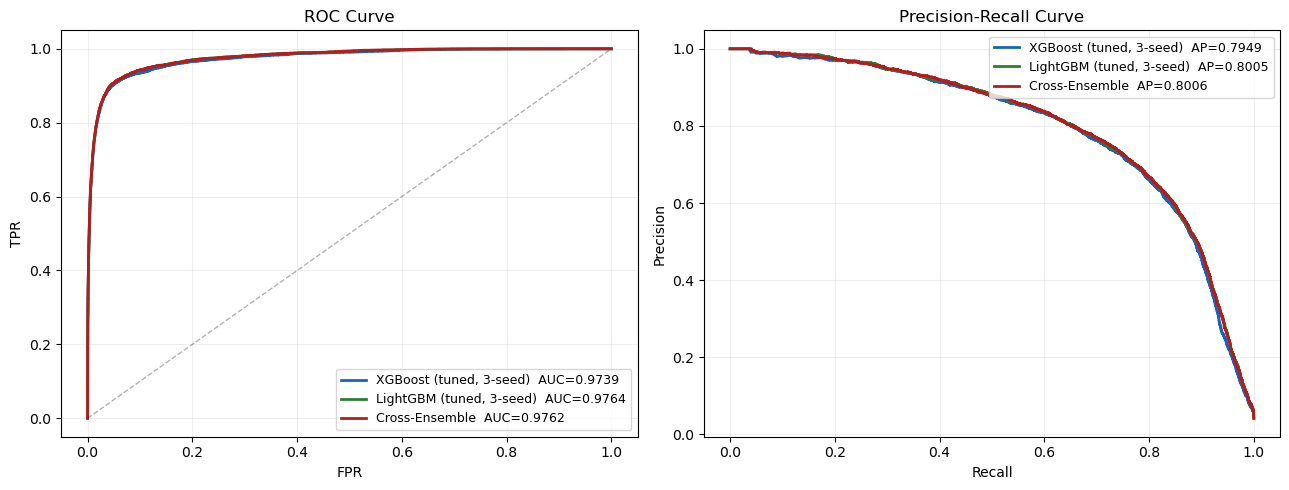

In [19]:
print('=== Individual models ===')
xgb_r  = evaluate('XGBoost (tuned, 3-seed)',  xgb_val,  xgb_test,  y_val, y_test)
print()
lgbm_r = evaluate('LightGBM (tuned, 3-seed)', lgbm_val, lgbm_test, y_val, y_test)
print()
print(f'=== Cross-Ensemble ({XGB_WEIGHT:.2f}×XGB + {LGBM_WEIGHT:.2f}×LGBM) ===')
ens_r  = evaluate('Cross-Ensemble',            ens_val,  ens_test,  y_val, y_test)
plot_curves([xgb_r, lgbm_r, ens_r])

## 8. Agreement Analysis

In [21]:
# ── Agreement analysis ────────────────────────────────────────
xgb_hi = xgb_test > 0.5; lgbm_hi = lgbm_test > 0.5
both_hi  = xgb_hi  & lgbm_hi
both_lo  = ~xgb_hi & ~lgbm_hi
disagree = xgb_hi  ^ lgbm_hi   # XOR

y_arr = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.array(y_test)
print('Agreement analysis (threshold 0.5):')
for label, mask in [('Both predict Sybil',  both_hi),
                    ('Both predict Clean',   both_lo),
                    ('Models disagree',      disagree)]:
    n_total = mask.sum(); n_correct_ens = ((ens_test[mask]>0.5)==y_arr[mask]).sum()
    n_sybil_in = (y_arr[mask]==1).sum()
    print(f'  {label:<26}: {n_total:6,} addresses  '
          f'({n_sybil_in:,} true Sybil, {n_total-n_sybil_in:,} true Clean)  '
          f'Ens correct: {n_correct_ens:,}/{n_total:,}')

print(f'\nDisagreement zone = {disagree.mean()*100:.2f}% of test set')
print('The ensemble primarily adds value in the disagreement zone by soft-voting.')

Agreement analysis (threshold 0.5):
  Both predict Sybil        :  5,480 addresses  (4,027 true Sybil, 1,453 true Clean)  Ens correct: 4,027/5,480
  Both predict Clean        : 124,271 addresses  (1,199 true Sybil, 123,072 true Clean)  Ens correct: 123,072/124,271
  Models disagree           :    686 addresses  (237 true Sybil, 449 true Clean)  Ens correct: 366/686

Disagreement zone = 0.53% of test set
The ensemble primarily adds value in the disagreement zone by soft-voting.


## 9. Operating Point Table

In [22]:
# ── Operating point table — cross-ensemble ────────────────────
n_sybil = int(y_test.sum()); n_clean = len(y_test) - n_sybil
print(f'\nTest set: {len(y_test):,} total | {n_sybil:,} Sybil | {n_clean:,} Non-Sybil\n')
print(f'  {"Threshold":<10} {"Precision":<11} {"Recall":<10} {"F1":<9} {"Flagged":<11} {"False+"}')
print('-'*65)
for t in [0.95, 0.90, 0.85, 0.80, 0.75, 0.70, round(ens_r["threshold"], 2), 0.50]:
    y_pred = (ens_test >= t).astype(int)
    if y_pred.sum() == 0: continue
    tp_ = int(((y_pred==1)&(y_test==1)).sum()); fp_ = int(((y_pred==1)&(y_test==0)).sum())
    p = tp_/(tp_+fp_); r = tp_/n_sybil; f1v = 2*p*r/(p+r) if p+r>0 else 0
    mark = ' ←opt' if abs(t - ens_r['threshold']) < 0.03 else ''
    print(f'  {t:<10.2f} {p:<11.4f} {r:<10.4f} {f1v:<9.4f} {y_pred.sum():<11,} {fp_:,}{mark}')


Test set: 130,437 total | 5,463 Sybil | 124,974 Non-Sybil

  Threshold  Precision   Recall     F1        Flagged     False+
-----------------------------------------------------------------
  0.95       0.8748      0.5105     0.6448    3,188       399
  0.90       0.8459      0.5817     0.6894    3,757       579
  0.85       0.8232      0.6205     0.7077    4,118       728
  0.80       0.8037      0.6460     0.7163    4,391       862
  0.75       0.7893      0.6692     0.7243    4,632       976
  0.70       0.7743      0.6934     0.7316    4,892       1,104
  0.55       0.7296      0.7461     0.7377    5,587       1,511 ←opt
  0.50       0.7143      0.7600     0.7364    5,813       1,661


## Summary

Test-set metrics for XGBoost, LightGBM, and the cross-ensemble are printed in section 7 and saved to `results/04_cross_ensemble_<split>.json`. The blend weight and the thresholds are chosen on the validation set; the test set is used only for the final report.

## Save Results

Scalar metrics go to `results/<notebook>_<split>.json` with the code commit, so every number in the paper can be traced to one run.

In [ ]:
sp.save_results([xgb_r, lgbm_r, ens_r], '04_cross_ensemble', SPLIT_METHOD, leakage=leak,
                extra=dict(xgb_weight=XGB_WEIGHT,
                           val_f1_by_weight=dict(zip(weights.tolist(), val_f1.round(4).tolist())),
                           params=dict(xgb=XGB_SELECTED, lgbm=LGBM_SELECTED),
                           rounds=dict(xgb=xgb_rounds, lgbm=lgbm_rounds),
                           disagreement_n=int(disagree.sum()),
                           disagreement_pct=float(disagree.mean() * 100)))

# ── Test predictions (read by 06_split_comparison for per-category metrics) ──
os.makedirs('output', exist_ok=True)
pred = pd.DataFrame({'addr': df.loc[S['idx_test'], 'addr'].to_numpy(),
                     'category': df.loc[S['idx_test'], 'category'].to_numpy(),
                     'y': y_test.to_numpy(), 'prob_xgb': xgb_test, 'prob_lgbm': lgbm_test, 'prob_ens': ens_test})
pred.to_parquet(f'output/pred_04_cross_ensemble_{SPLIT_METHOD}.parquet', index=False)
print(f'Saved output/pred_04_cross_ensemble_{SPLIT_METHOD}.parquet ({len(pred):,} rows)')